# Incremental Update Evaluation (OE)

This notebook evaluates the update method in `deliverables/update_model_incremental.py`.

For each `n` from `1` to `(#days - 2)`:
1. Train baseline models using days `1..n` only (via `deliverables/model_training.py`).
2. Evaluate baseline MAE on day `n+2`.
3. Update models using day `n+1` as `--new_data` (via `deliverables/update_model_incremental.py`).
4. Re-evaluate MAE on day `n+2`.
5. Compare MAE change and model-parameter change (feature-importance vectors + tree counts).

Notes:
- XGBoost tree models do not have linear coefficients; this notebook uses feature-importance vectors (gain) as a coefficient proxy.
- Runtime can be long because this retrains models repeatedly.


In [1]:
import os
import sys
import json
import math
import shutil
import pickle
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'Model_Jiashen' else Path.cwd().resolve()
if (REPO_ROOT / 'deliverables').exists() is False:
    raise FileNotFoundError(f'Could not find deliverables/ from {REPO_ROOT}')

DELIVERABLES_DIR = REPO_ROOT / 'deliverables'
if str(DELIVERABLES_DIR) not in sys.path:
    sys.path.insert(0, str(DELIVERABLES_DIR))

from utils.data_pipeline import prepare_new_data
from utils.io import load_meta, load_model


In [2]:
# ---- Configuration ----
WAREHOUSE = 'OE'
TARGET_WORKCODE = '30'  # single-workcode mode

SOURCE_DATA_DIR = REPO_ROOT / 'deliverables' / 'training_data'
SOURCE_WH_DIR = SOURCE_DATA_DIR / WAREHOUSE
SOURCE_PARQUET = SOURCE_WH_DIR / f'{WAREHOUSE}_Processed.parquet'

MODEL_TRAINING_SCRIPT = REPO_ROOT / 'deliverables' / 'model_training.py'
UPDATE_SCRIPT = REPO_ROOT / 'deliverables' / 'update_model_incremental.py'

ARTIFACTS_ROOT = REPO_ROOT / 'Model_Jiashen' / f'incremental_eval_artifacts_wc{TARGET_WORKCODE}'
ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)

TRAIN_TREES = 1200
TRAIN_MIN_ROWS = 500
UPDATE_TREES = 150
SEQUENCED = False

MAX_N = None
RUN_FULL_EXPERIMENT = True
OVERWRITE_RUNS = False

print('REPO_ROOT:', REPO_ROOT)
print('SOURCE_PARQUET exists:', SOURCE_PARQUET.exists())
print('TARGET_WORKCODE:', TARGET_WORKCODE)
print('ARTIFACTS_ROOT:', ARTIFACTS_ROOT)


REPO_ROOT: /Users/jiashenwang/Desktop/Lucas_Systems_Capstone_Project
SOURCE_PARQUET exists: True
TARGET_WORKCODE: 30
ARTIFACTS_ROOT: /Users/jiashenwang/Desktop/Lucas_Systems_Capstone_Project/Model_Jiashen/incremental_eval_artifacts_wc30


In [3]:
# ---- Load OE processed data, filter to one WorkCode, derive calendar days ----
if not SOURCE_PARQUET.exists():
    raise FileNotFoundError(f'Missing source parquet: {SOURCE_PARQUET}')

full_df = pd.read_parquet(SOURCE_PARQUET)
full_df['Timestamp'] = pd.to_datetime(full_df['Timestamp'], errors='coerce')
full_df = full_df.dropna(subset=['Timestamp']).copy()

# Normalize WorkCode to match training/update script conventions
full_df['WorkCode'] = (
    full_df['WorkCode'].astype(str)
    .apply(lambda x: x.split('.')[0] if isinstance(x, str) else x)
)
full_df = full_df[full_df['WorkCode'] == str(TARGET_WORKCODE)].copy()

if full_df.empty:
    raise ValueError(f'No rows found for WorkCode={TARGET_WORKCODE} in {SOURCE_PARQUET}')

full_df['Date'] = full_df['Timestamp'].dt.date

all_days = sorted(full_df['Date'].unique().tolist())
print('Total rows (filtered):', len(full_df))
print('Target WorkCode:', TARGET_WORKCODE)
print('Total distinct days:', len(all_days))
print('First day:', all_days[0] if all_days else None)
print('Last day :', all_days[-1] if all_days else None)

if len(all_days) < 3:
    raise ValueError('Need at least 3 days to evaluate n, n+1, n+2 logic.')


Total rows (filtered): 66454
Target WorkCode: 30
Total distinct days: 8
First day: 2025-09-08
Last day : 2025-12-02


In [4]:
# ---- Helper functions ----
ACTIVITY_COLS = [
    'ActivityCode', 'UserID', 'WorkCode', 'AssignmentID',
    'ProductID', 'Quantity', 'Timestamp', 'LocationID'
]


def ensure_wh_reference_tables(dst_wh_dir: Path, src_wh_dir: Path):
    dst_wh_dir.mkdir(parents=True, exist_ok=True)
    for p in src_wh_dir.glob('*.csv'):
        shutil.copy2(p, dst_wh_dir / p.name)


def write_processed_subset(train_df: pd.DataFrame, dst_data_dir: Path, warehouse: str):
    wh_dir = dst_data_dir / warehouse
    wh_dir.mkdir(parents=True, exist_ok=True)
    out_parquet = wh_dir / f'{warehouse}_Processed.parquet'
    train_df.to_parquet(out_parquet, index=False)
    return out_parquet


def write_activity_csv(day_df: pd.DataFrame, out_csv: Path):
    missing = [c for c in ACTIVITY_COLS if c not in day_df.columns]
    if missing:
        raise ValueError(f'Missing required activity columns: {missing}')
    tmp = day_df[ACTIVITY_COLS].copy()
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    tmp.to_csv(out_csv, index=False)
    return out_csv


def run_cmd(cmd, cwd: Path):
    res = subprocess.run(cmd, cwd=str(cwd), capture_output=True, text=True)
    if res.returncode != 0:
        print('Command failed:', ' '.join(cmd))
        print('STDOUT:', res.stdout[-3000:])
        print('STDERR:', res.stderr[-3000:])
    return res


def feature_gain_vector(model: xgb.Booster, train_columns):
    score = model.get_score(importance_type='gain')
    vec = pd.Series({c: float(score.get(c, 0.0)) for c in train_columns}, dtype=float)
    return vec


def cosine_similarity(a: np.ndarray, b: np.ndarray):
    an = np.linalg.norm(a)
    bn = np.linalg.norm(b)
    if an == 0 or bn == 0:
        return np.nan
    return float(np.dot(a, b) / (an * bn))


def evaluate_on_activity(models_dir: Path, data_dir: Path, warehouse: str, activity_csv: Path, target_workcode: str, sequenced: bool=False):
    meta = load_meta(str(models_dir), warehouse)

    per_wc = []
    abs_err_sum = 0.0
    n_total = 0

    for wc in meta.get('workcodes', []):
        if str(wc) != str(target_workcode):
            continue

        wc_enc = dict(meta.get('encodings', {}).get(wc, {}))
        wc_enc['train_columns'] = meta.get('train_columns', {}).get(wc)

        try:
            df, X, y = prepare_new_data(
                activity_csv=str(activity_csv),
                data_dir=str(data_dir),
                warehouse=warehouse,
                wc=wc,
                encodings=wc_enc,
                sequenced=sequenced,
            )
        except Exception:
            continue

        effects_df = meta.get('worker_effects', {}).get(wc)
        if effects_df is None or len(effects_df) == 0:
            worker_effect = pd.Series(0.0, index=df.index)
        else:
            tmp = df.merge(effects_df[['UserID', 'worker_effect']], on='UserID', how='left')
            worker_effect = tmp['worker_effect'].fillna(0.0)

        X = X.copy()
        X['worker_effect'] = worker_effect.values
        X = X.reindex(columns=meta['train_columns'][wc], fill_value=0)

        model = load_model(str(models_dir), warehouse, wc, sequenced=sequenced)
        pred = model.predict(xgb.DMatrix(X))

        abs_err = np.abs(pred - y.values)
        mae_wc = float(abs_err.mean()) if len(abs_err) else np.nan

        per_wc.append({
            'workcode': wc,
            'rows': int(len(y)),
            'mae': mae_wc,
            'trees': int(model.num_boosted_rounds()),
        })

        abs_err_sum += float(abs_err.sum())
        n_total += int(len(abs_err))

    overall_mae = abs_err_sum / n_total if n_total > 0 else np.nan
    return overall_mae, pd.DataFrame(per_wc), meta


def model_coef_snapshot(models_dir: Path, warehouse: str, target_workcode: str, sequenced: bool=False):
    meta = load_meta(str(models_dir), warehouse)

    rows = []
    vectors = {}

    for wc in meta.get('workcodes', []):
        if str(wc) != str(target_workcode):
            continue

        cols = meta.get('train_columns', {}).get(wc, [])
        model = load_model(str(models_dir), warehouse, wc, sequenced=sequenced)
        vec = feature_gain_vector(model, cols)
        vectors[wc] = vec
        rows.append({
            'workcode': wc,
            'trees': int(model.num_boosted_rounds()),
            'gain_sum': float(vec.sum()),
            'gain_nonzero_features': int((vec != 0).sum()),
        })

    return pd.DataFrame(rows), vectors, meta


In [5]:
# ---- Rolling experiment loop (single WorkCode) ----
python_exe = sys.executable
n_max_candidate = len(all_days) - 2
n_values = list(range(1, n_max_candidate + 1))
if MAX_N is not None:
    n_values = [n for n in n_values if n <= MAX_N]

print(f'Will evaluate {len(n_values)} values of n (max possible={n_max_candidate}) for WorkCode={TARGET_WORKCODE}.')

summary_rows = []
wc_mae_rows = []
coef_change_rows = []

if RUN_FULL_EXPERIMENT:
    for n in n_values:
        train_end_day = all_days[n-1]
        update_day = all_days[n]
        test_day = all_days[n+1]

        run_dir = ARTIFACTS_ROOT / f'n_{n:04d}'
        run_data_dir = run_dir / 'training_data'
        run_models_dir = run_dir / 'models'
        run_wh_data_dir = run_data_dir / WAREHOUSE

        if run_dir.exists() and OVERWRITE_RUNS:
            shutil.rmtree(run_dir)

        run_dir.mkdir(parents=True, exist_ok=True)

        train_days = set(all_days[:n])
        train_df = full_df[full_df['Date'].isin(train_days)].copy()

        ensure_wh_reference_tables(run_wh_data_dir, SOURCE_WH_DIR)
        write_processed_subset(train_df.drop(columns=['Date']), run_data_dir, WAREHOUSE)

        update_df = full_df[full_df['Date'] == update_day].copy()
        test_df = full_df[full_df['Date'] == test_day].copy()
        update_csv = write_activity_csv(update_df, run_dir / f'update_day_{update_day}_wc{TARGET_WORKCODE}.csv')
        test_csv = write_activity_csv(test_df, run_dir / f'test_day_{test_day}_wc{TARGET_WORKCODE}.csv')

        cmd_train = [
            python_exe, str(MODEL_TRAINING_SCRIPT), WAREHOUSE,
            '--data_dir', str(run_data_dir),
            '--models_dir', str(run_models_dir),
            '--trees', str(TRAIN_TREES),
            '--min_rows', str(TRAIN_MIN_ROWS),
        ]
        if SEQUENCED:
            cmd_train.append('--sequenced')

        train_res = run_cmd(cmd_train, cwd=DELIVERABLES_DIR)
        if train_res.returncode != 0:
            summary_rows.append({
                'n': n,
                'target_workcode': str(TARGET_WORKCODE),
                'train_end_day': train_end_day,
                'update_day': update_day,
                'test_day': test_day,
                'status': 'train_failed',
            })
            continue

        meta_path = run_models_dir / WAREHOUSE / 'meta.pkl'
        if not meta_path.exists():
            summary_rows.append({
                'n': n,
                'target_workcode': str(TARGET_WORKCODE),
                'train_end_day': train_end_day,
                'update_day': update_day,
                'test_day': test_day,
                'status': 'no_models_trained',
            })
            continue

        coef_before_df, vec_before, _ = model_coef_snapshot(
            run_models_dir, WAREHOUSE, target_workcode=TARGET_WORKCODE, sequenced=SEQUENCED
        )
        mae_before, wc_before_df, _ = evaluate_on_activity(
            run_models_dir, run_data_dir, WAREHOUSE, test_csv,
            target_workcode=TARGET_WORKCODE, sequenced=SEQUENCED
        )

        cmd_update = [
            python_exe, str(UPDATE_SCRIPT), WAREHOUSE,
            '--new_data', str(update_csv),
            '--data_dir', str(run_data_dir),
            '--models_dir', str(run_models_dir),
            '--trees', str(UPDATE_TREES),
        ]
        if SEQUENCED:
            cmd_update.append('--sequenced')

        upd_res = run_cmd(cmd_update, cwd=DELIVERABLES_DIR)
        if upd_res.returncode != 0:
            summary_rows.append({
                'n': n,
                'target_workcode': str(TARGET_WORKCODE),
                'train_end_day': train_end_day,
                'update_day': update_day,
                'test_day': test_day,
                'status': 'update_failed',
                'mae_before': mae_before,
            })
            continue

        coef_after_df, vec_after, _ = model_coef_snapshot(
            run_models_dir, WAREHOUSE, target_workcode=TARGET_WORKCODE, sequenced=SEQUENCED
        )
        mae_after, wc_after_df, _ = evaluate_on_activity(
            run_models_dir, run_data_dir, WAREHOUSE, test_csv,
            target_workcode=TARGET_WORKCODE, sequenced=SEQUENCED
        )

        summary_rows.append({
            'n': n,
            'target_workcode': str(TARGET_WORKCODE),
            'train_end_day': train_end_day,
            'update_day': update_day,
            'test_day': test_day,
            'status': 'ok',
            'train_rows': int(len(train_df)),
            'update_rows': int(len(update_df)),
            'test_rows_raw': int(len(test_df)),
            'mae_before': float(mae_before) if pd.notna(mae_before) else np.nan,
            'mae_after': float(mae_after) if pd.notna(mae_after) else np.nan,
            'delta_mae': (float(mae_after) - float(mae_before)) if pd.notna(mae_before) and pd.notna(mae_after) else np.nan,
            'delta_mae_pct': ((float(mae_after) - float(mae_before)) / float(mae_before) * 100.0)
                              if pd.notna(mae_before) and pd.notna(mae_after) and float(mae_before) != 0 else np.nan,
        })

        wc_merge = wc_before_df.merge(wc_after_df, on='workcode', how='outer', suffixes=('_before', '_after'))
        wc_merge['n'] = n
        wc_merge['target_workcode'] = str(TARGET_WORKCODE)
        wc_merge['delta_mae'] = wc_merge['mae_after'] - wc_merge['mae_before']
        wc_merge['delta_trees'] = wc_merge['trees_after'] - wc_merge['trees_before']
        wc_mae_rows.extend(wc_merge.to_dict(orient='records'))

        for wc in sorted(set(vec_before.keys()).intersection(vec_after.keys())):
            v0 = vec_before[wc].astype(float)
            v1 = vec_after[wc].reindex(v0.index, fill_value=0.0).astype(float)
            diff = v1.values - v0.values

            coef_change_rows.append({
                'n': n,
                'target_workcode': str(TARGET_WORKCODE),
                'workcode': wc,
                'coef_l1_change': float(np.abs(diff).sum()),
                'coef_l2_change': float(np.sqrt((diff ** 2).sum())),
                'coef_cosine_similarity': cosine_similarity(v0.values, v1.values),
                'gain_sum_before': float(v0.sum()),
                'gain_sum_after': float(v1.sum()),
                'delta_gain_sum': float(v1.sum() - v0.sum()),
                'nonzero_features_before': int((v0 != 0).sum()),
                'nonzero_features_after': int((v1 != 0).sum()),
                'delta_nonzero_features': int((v1 != 0).sum() - (v0 != 0).sum()),
            })

        print(f'n={n}: WC={TARGET_WORKCODE}, MAE before={mae_before:.4f}, after={mae_after:.4f}, delta={mae_after-mae_before:+.4f}')

    print('Experiment finished.')
else:
    print('RUN_FULL_EXPERIMENT=False, skipping heavy execution.')


Will evaluate 6 values of n (max possible=6) for WorkCode=30.
n=1: WC=30, MAE before=35.3654, after=34.8429, delta=-0.5225
n=2: WC=30, MAE before=34.9569, after=33.7767, delta=-1.1802
n=3: WC=30, MAE before=31.6444, after=31.0866, delta=-0.5579
n=4: WC=30, MAE before=30.7098, after=30.4015, delta=-0.3083
n=5: WC=30, MAE before=31.6547, after=30.4025, delta=-1.2521
n=6: WC=30, MAE before=32.1845, after=31.6841, delta=-0.5004
Experiment finished.


In [6]:
# ---- Build result DataFrames ----
summary_df = pd.DataFrame(summary_rows)
wc_mae_df = pd.DataFrame(wc_mae_rows)
coef_change_df = pd.DataFrame(coef_change_rows)

print('summary_df:', summary_df.shape)
print('wc_mae_df:', wc_mae_df.shape)
print('coef_change_df:', coef_change_df.shape)

if not summary_df.empty:
    display(summary_df.head())
if not wc_mae_df.empty:
    display(wc_mae_df.head())
if not coef_change_df.empty:
    display(coef_change_df.head())


summary_df: (6, 13)
wc_mae_df: (6, 11)
coef_change_df: (6, 12)


,n,target_workcode,train_end_day,update_day,test_day,status,train_rows,update_rows,test_rows_raw,mae_before,mae_after,delta_mae,delta_mae_pct
0,1,30,2025-09-08,2025-09-09,2025-11-10,ok,9637,6116,10183,35.365404,34.842942,-0.522462,-1.477325
1,2,30,2025-09-09,2025-11-10,2025-11-11,ok,15753,10183,6894,34.956921,33.776717,-1.180204,-3.376166
2,3,30,2025-11-10,2025-11-11,2025-11-12,ok,25936,6894,7294,31.644449,31.086586,-0.557864,-1.762912
3,4,30,2025-11-11,2025-11-12,2025-11-13,ok,32830,7294,8393,30.709804,30.401488,-0.308316,-1.003966
4,5,30,2025-11-12,2025-11-13,2025-12-01,ok,40124,8393,10955,31.654661,30.402527,-1.252134,-3.955606


,workcode,rows_before,mae_before,trees_before,rows_after,mae_after,trees_after,n,target_workcode,delta_mae,delta_trees
0,30,9951,35.365404,1200,9951,34.842942,1350,1,30,-0.522462,150
1,30,6728,34.956921,1200,6728,33.776717,1350,2,30,-1.180204,150
2,30,7121,31.644449,1200,7121,31.086586,1350,3,30,-0.557864,150
3,30,8198,30.709804,1200,8198,30.401488,1350,4,30,-0.308316,150
4,30,10709,31.654661,1200,10709,30.402527,1350,5,30,-1.252134,150


,n,target_workcode,workcode,coef_l1_change,coef_l2_change,coef_cosine_similarity,gain_sum_before,gain_sum_after,delta_gain_sum,nonzero_features_before,nonzero_features_after,delta_nonzero_features
0,1,30,30,157.925884,38.776349,0.988035,638.707546,792.497154,153.789608,22,22,0
1,2,30,30,138.616333,31.742676,0.995771,782.955959,921.572292,138.616333,22,22,0
2,3,30,30,59.639732,14.902709,0.998616,1033.182846,1083.500107,50.317261,22,22,0
3,4,30,30,49.118893,15.378832,0.998565,1190.756695,1200.668869,9.912174,22,22,0
4,5,30,30,31.774368,15.293848,0.999403,1340.066696,1316.072159,-23.994537,22,22,0


In [7]:
# ---- Optional: load cached CSV results ----
cache_dir = ARTIFACTS_ROOT / 'results_cache'
cache_dir.mkdir(parents=True, exist_ok=True)

summary_csv = cache_dir / 'summary.csv'
wc_mae_csv = cache_dir / 'wc_mae.csv'
coef_csv = cache_dir / 'coef_change.csv'

if summary_df.empty and summary_csv.exists():
    summary_df = pd.read_csv(summary_csv)
if wc_mae_df.empty and wc_mae_csv.exists():
    wc_mae_df = pd.read_csv(wc_mae_csv)
if coef_change_df.empty and coef_csv.exists():
    coef_change_df = pd.read_csv(coef_csv)

print('Loaded/cached shapes:')
print('summary_df:', summary_df.shape)
print('wc_mae_df:', wc_mae_df.shape)
print('coef_change_df:', coef_change_df.shape)


Loaded/cached shapes:
summary_df: (6, 13)
wc_mae_df: (6, 11)
coef_change_df: (6, 12)


In [8]:
# ---- Save results to disk ----
if not summary_df.empty:
    cache_dir = ARTIFACTS_ROOT / 'results_cache'
    cache_dir.mkdir(parents=True, exist_ok=True)
    summary_df.to_csv(cache_dir / 'summary.csv', index=False)
    wc_mae_df.to_csv(cache_dir / 'wc_mae.csv', index=False)
    coef_change_df.to_csv(cache_dir / 'coef_change.csv', index=False)
    print('Saved result CSVs to', cache_dir)
else:
    print('No results to save yet.')


Saved result CSVs to /Users/jiashenwang/Desktop/Lucas_Systems_Capstone_Project/Model_Jiashen/incremental_eval_artifacts_wc30/results_cache


OK runs: 6
Mean delta_mae: -0.7202298017442536
Median delta_mae: -0.5401628872936737
Frac improved (delta_mae < 0): 1.0


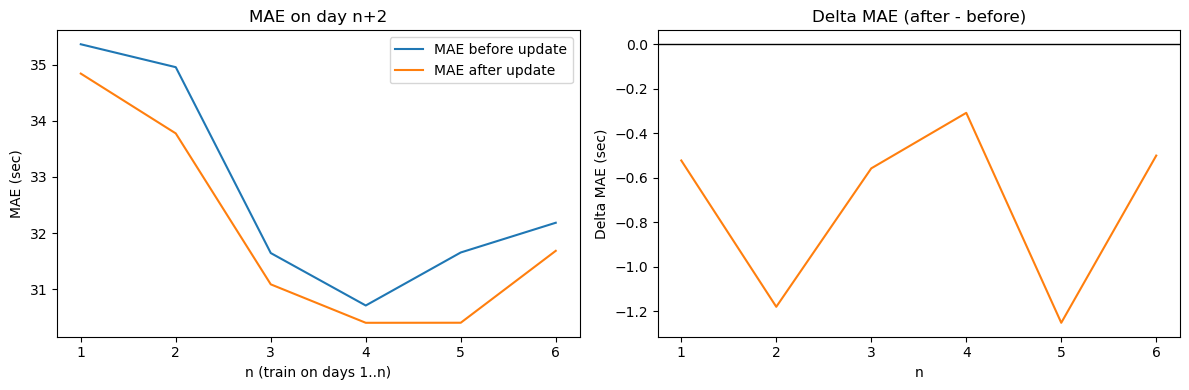

In [9]:
# ---- Analysis: MAE change ----
if summary_df.empty:
    print('No summary results available.')
else:
    ok = summary_df[summary_df['status'] == 'ok'].copy()
    print('OK runs:', len(ok))

    if len(ok) > 0:
        print('Mean delta_mae:', ok['delta_mae'].mean())
        print('Median delta_mae:', ok['delta_mae'].median())
        print('Frac improved (delta_mae < 0):', (ok['delta_mae'] < 0).mean())

        fig, ax = plt.subplots(1, 2, figsize=(12, 4))

        ax[0].plot(ok['n'], ok['mae_before'], label='MAE before update')
        ax[0].plot(ok['n'], ok['mae_after'], label='MAE after update')
        ax[0].set_title('MAE on day n+2')
        ax[0].set_xlabel('n (train on days 1..n)')
        ax[0].set_ylabel('MAE (sec)')
        ax[0].legend()

        ax[1].axhline(0, color='black', linewidth=1)
        ax[1].plot(ok['n'], ok['delta_mae'], color='tab:orange')
        ax[1].set_title('Delta MAE (after - before)')
        ax[1].set_xlabel('n')
        ax[1].set_ylabel('Delta MAE (sec)')

        plt.tight_layout()
        plt.show()


Avg L1 change: 84.81998380025227
Avg L2 change: 23.193430474357317
Avg cosine similarity: 0.9964641794234481


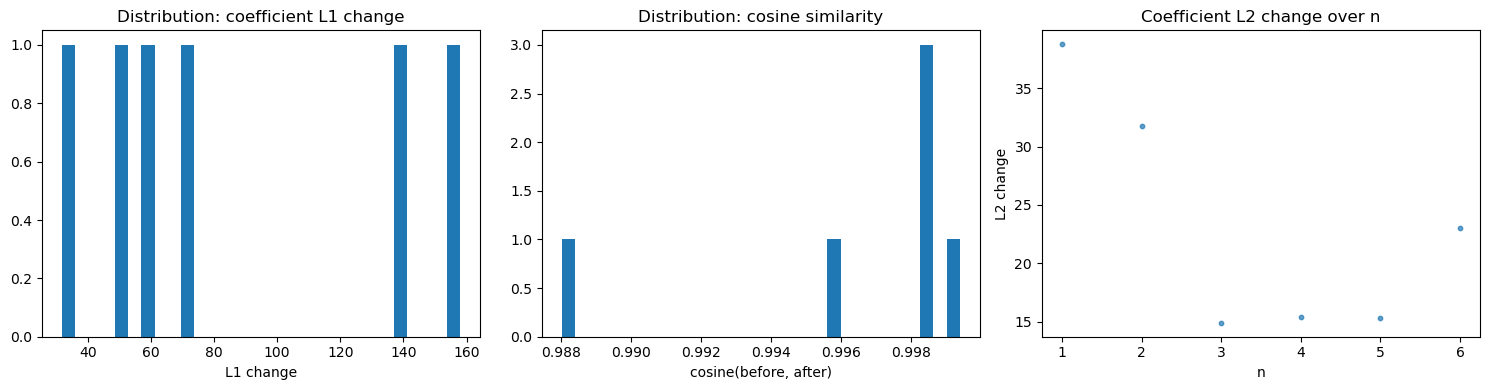

In [10]:
# ---- Analysis: coefficient/proxy change extent ----
if coef_change_df.empty:
    print('No coefficient-change results available.')
else:
    c = coef_change_df.copy()

    print('Avg L1 change:', c['coef_l1_change'].mean())
    print('Avg L2 change:', c['coef_l2_change'].mean())
    print('Avg cosine similarity:', c['coef_cosine_similarity'].mean(skipna=True))

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))

    ax[0].hist(c['coef_l1_change'].dropna(), bins=30)
    ax[0].set_title('Distribution: coefficient L1 change')
    ax[0].set_xlabel('L1 change')

    ax[1].hist(c['coef_cosine_similarity'].dropna(), bins=30)
    ax[1].set_title('Distribution: cosine similarity')
    ax[1].set_xlabel('cosine(before, after)')

    ax[2].scatter(c['n'], c['coef_l2_change'], s=10, alpha=0.7)
    ax[2].set_title('Coefficient L2 change over n')
    ax[2].set_xlabel('n')
    ax[2].set_ylabel('L2 change')

    plt.tight_layout()
    plt.show()


,n,delta_mae,mean_coef_l1_change,mean_coef_l2_change,mean_coef_cosine
0,1,-0.522462,157.925884,38.776349,0.988035
1,2,-1.180204,138.616333,31.742676,0.995771
2,3,-0.557864,59.639732,14.902709,0.998616
3,4,-0.308316,49.118893,15.378832,0.998565
4,5,-1.252134,31.774368,15.293848,0.999403


corr(delta_mae, mean_coef_l1_change)= -0.03679100068059133
corr(delta_mae, mean_coef_l2_change)= -0.062459554050723495
corr(delta_mae, mean_coef_cosine)= -0.1496167950757026


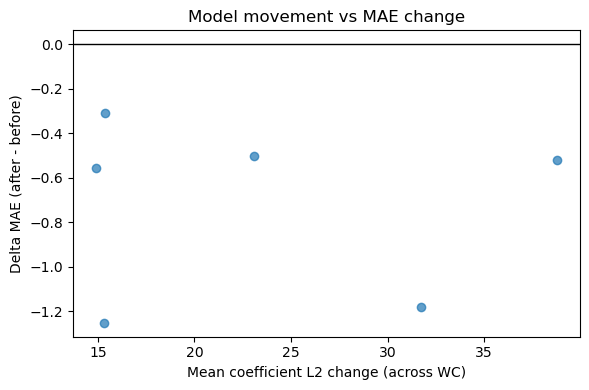

In [11]:
# ---- Joint view: parameter movement vs MAE change ----
if summary_df.empty or coef_change_df.empty:
    print('Need both summary and coefficient results.')
else:
    ok = summary_df[summary_df['status'] == 'ok'][['n', 'delta_mae']].copy()
    coef_agg = coef_change_df.groupby('n', as_index=False).agg(
        mean_coef_l1_change=('coef_l1_change', 'mean'),
        mean_coef_l2_change=('coef_l2_change', 'mean'),
        mean_coef_cosine=('coef_cosine_similarity', 'mean'),
    )
    joint = ok.merge(coef_agg, on='n', how='inner')

    display(joint.head())

    if len(joint) > 1:
        print('corr(delta_mae, mean_coef_l1_change)=', joint['delta_mae'].corr(joint['mean_coef_l1_change']))
        print('corr(delta_mae, mean_coef_l2_change)=', joint['delta_mae'].corr(joint['mean_coef_l2_change']))
        print('corr(delta_mae, mean_coef_cosine)=', joint['delta_mae'].corr(joint['mean_coef_cosine']))

        plt.figure(figsize=(6,4))
        plt.axhline(0, color='black', linewidth=1)
        plt.scatter(joint['mean_coef_l2_change'], joint['delta_mae'], alpha=0.7)
        plt.xlabel('Mean coefficient L2 change (across WC)')
        plt.ylabel('Delta MAE (after - before)')
        plt.title('Model movement vs MAE change')
        plt.tight_layout()
        plt.show()


## How to run

1. Open this notebook from `Model_Jiashen`.
2. Set `RUN_FULL_EXPERIMENT = True` in the config cell.
3. Optionally set `MAX_N` small for a smoke test first.
4. Run all cells.

Main outputs:
- `Model_Jiashen/incremental_eval_artifacts/`
- `Model_Jiashen/incremental_eval_artifacts/results_cache/summary.csv`
- `Model_Jiashen/incremental_eval_artifacts/results_cache/wc_mae.csv`
- `Model_Jiashen/incremental_eval_artifacts/results_cache/coef_change.csv`
